In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [23]:
df = pd.read_csv("../data/processed/customer_churn_clean.csv")

In [24]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


We'll perform:

Univariate Analysis:

-Churn

-Gender

-Senior Citizen

-Contract

-Internet Service

-Payment Method

-Monthly Charges

-Tenure

Bivariate Analysis:

-Relationship between Churn and

-Gender

-Senior Citizen

-Contract

-Internet Service

-Payment Method

-Tenure

-Monthly Charges


Multivariate Analysis:

-Correlation

-Pair relationships

-Business insights

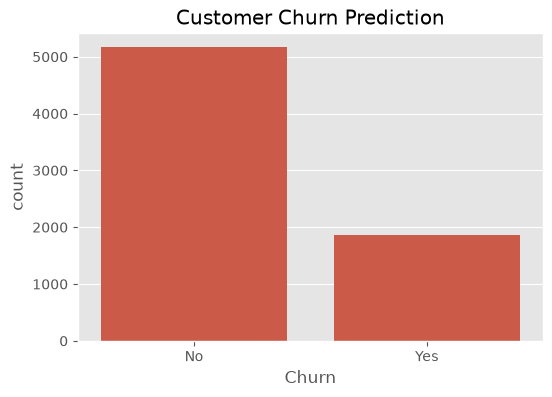

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Prediction")
plt.show()

Business Insight

Most customers did not churn, but approximately 27% did. This indicates moderate class imbalance.

Business Action

Retention strategies should focus on identifying customers likely to churn before they leave.

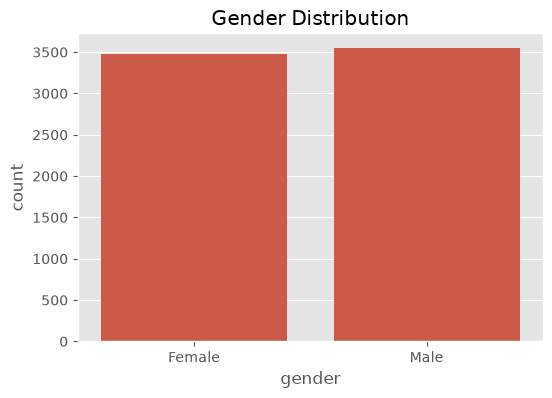

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,  x="gender")
plt.title("Gender Distribution")
plt.show()

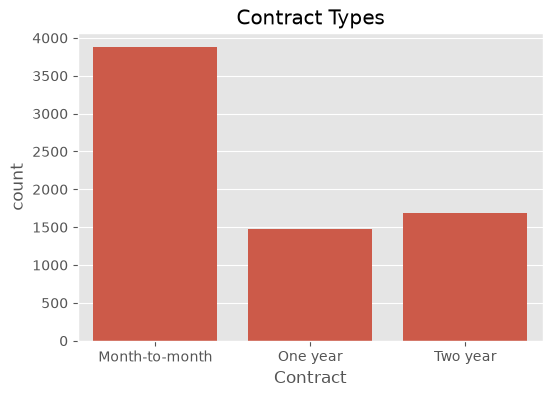

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Contract")
plt.title("Contract Types")
plt.show()


Text(0.5, 1.0, 'InternetService')

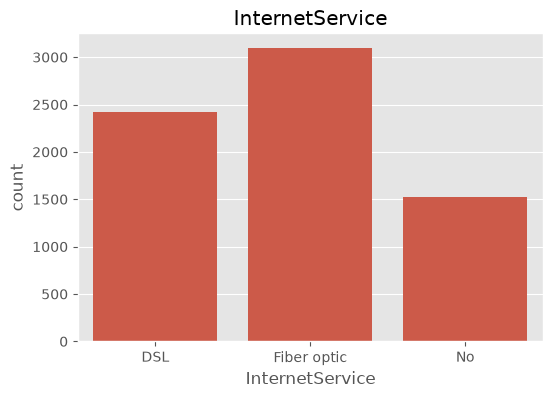

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="InternetService")
plt.title("InternetService")

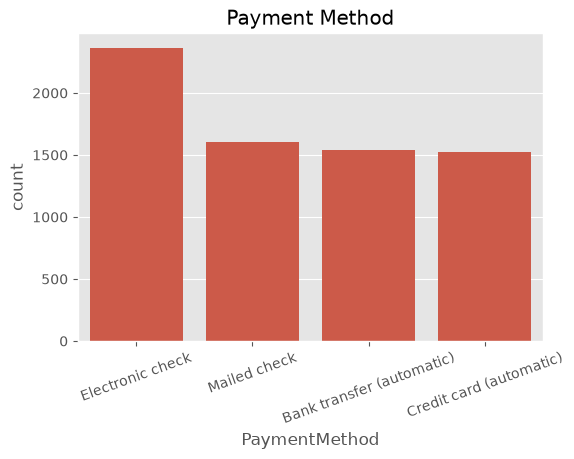

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="PaymentMethod")
plt.xticks(rotation=20)
plt.title("Payment Method")
plt.show()

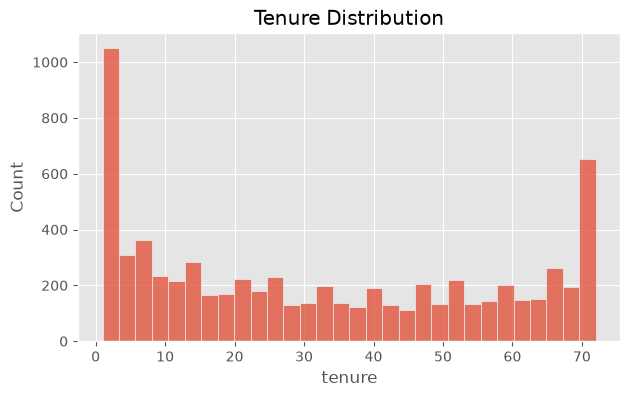

In [30]:
plt.figure(figsize=(7,4))

sns.histplot(df["tenure"], bins=30)

plt.title("Tenure Distribution")
plt.show()

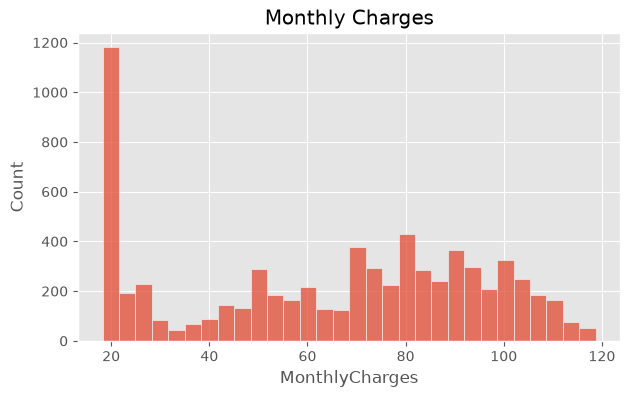

In [31]:
plt.figure(figsize=(7,4))

sns.histplot(df["MonthlyCharges"], bins=30)

plt.title("Monthly Charges")
plt.show()

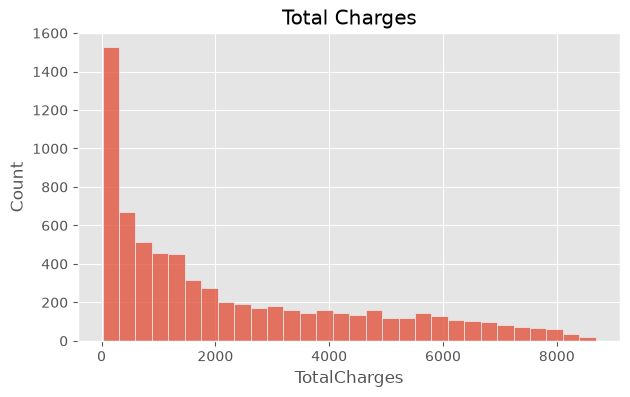

In [32]:
plt.figure(figsize=(7,4))

sns.histplot(df["TotalCharges"], bins=30)

plt.title("Total Charges")
plt.show()

Bivariate Analysis

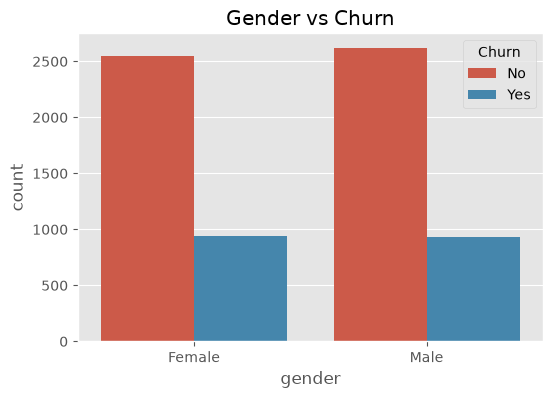

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="gender",
              hue="Churn")

plt.title("Gender vs Churn")
plt.show()

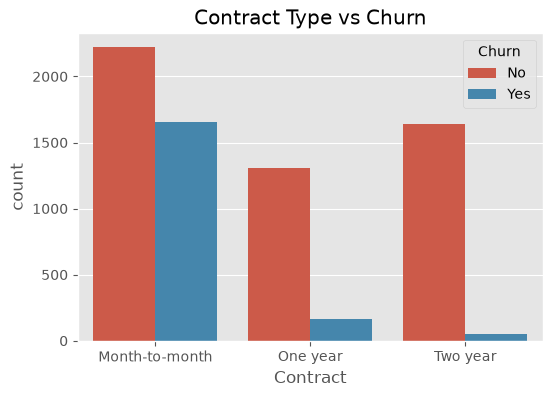

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.show()

Business Insight:

Customers with month-to-month contracts appear to churn much more frequently than customers on one-year or two-year contracts.

Business Action:

Encourage customers to switch to longer-term contracts through discounts or loyalty programs

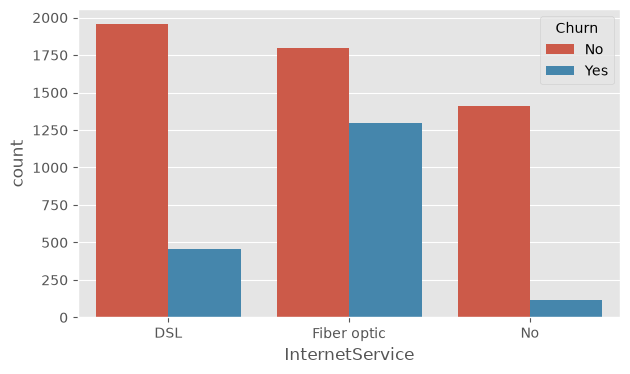

In [35]:
plt.figure(figsize=(7,4))

sns.countplot(data=df,
              x="InternetService",
              hue="Churn")

plt.show()

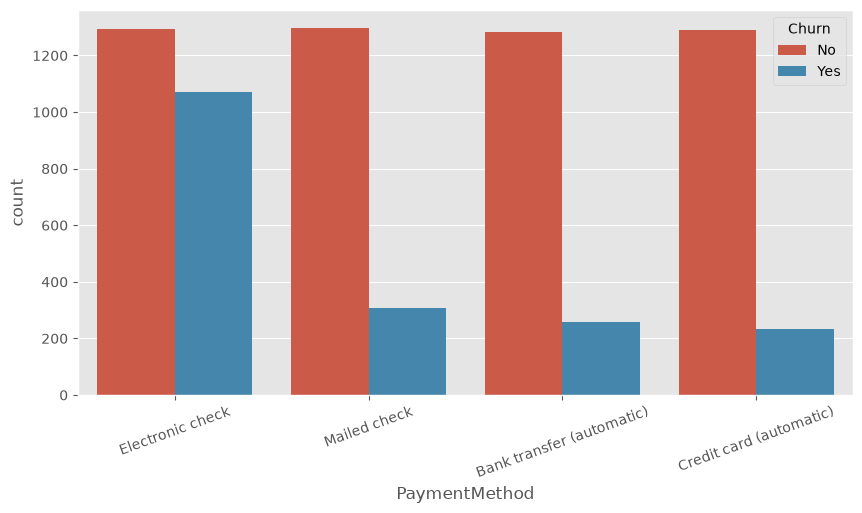

In [36]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="PaymentMethod",
              hue="Churn")

plt.xticks(rotation=20)

plt.show()

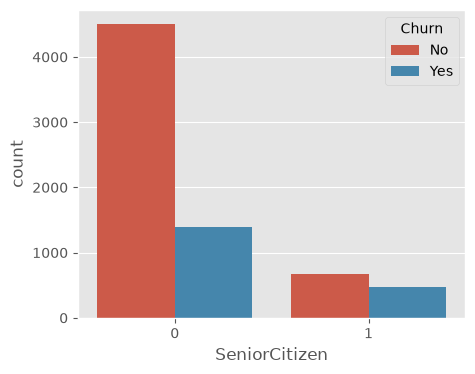

In [37]:
plt.figure(figsize=(5,4))

sns.countplot(data=df,
              x="SeniorCitizen",
              hue="Churn")

plt.show()

Numerical Relationships

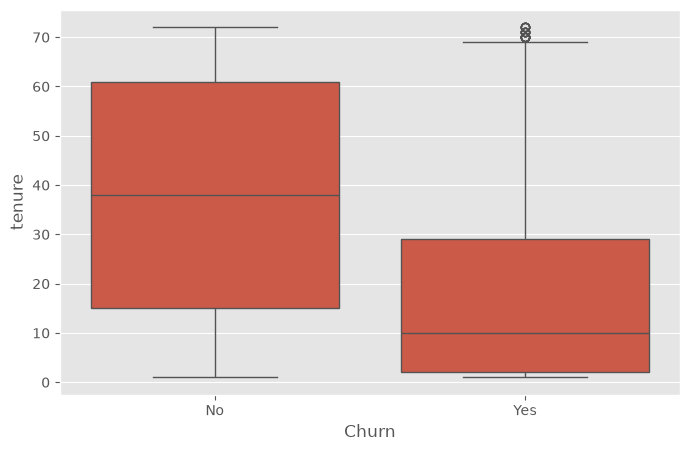

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="Churn",
            y="tenure")

plt.show()

Customers who churn generally have shorter tenure

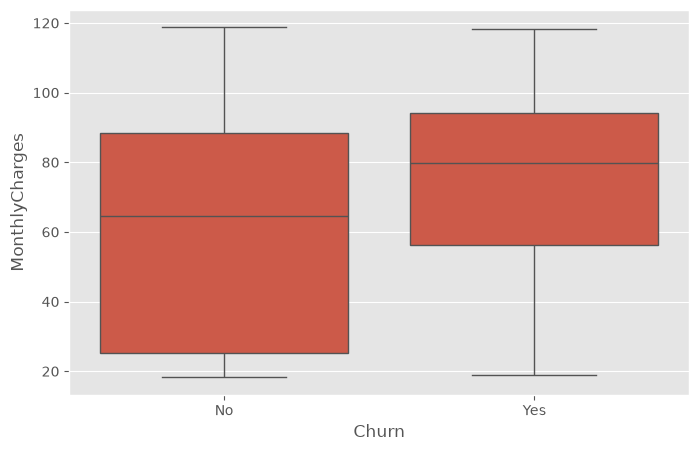

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn" ,y="MonthlyCharges")
plt.show()

Customers paying higher monthly charges tend to churn more often.

Correlation

First encode the target

In [40]:
df_corr = df.copy()

df_corr["Churn"] = df_corr["Churn"].map({
    "No":0,
    "Yes":1
})

In [41]:
numeric_df = df_corr.select_dtypes(include=["number"])

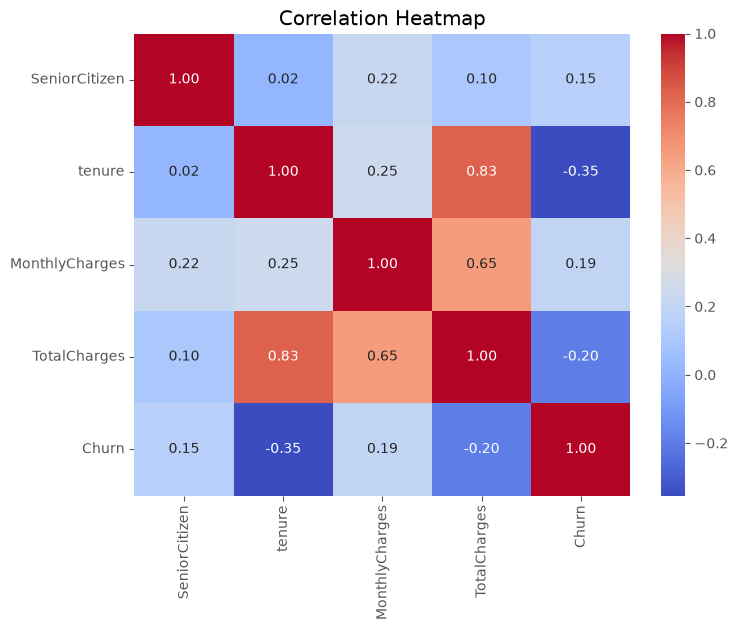

In [42]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

I found that tenure and TotalCharges have a strong positive correlation because customers who stay longer naturally accumulate higher charges. I also observed a moderate negative correlation between tenure and Churn, indicating that long-term customers are less likely to leave. MonthlyCharges showed a weak positive correlation with Churn, suggesting that customers paying higher monthly fees are somewhat more likely to churn. These insights supported both business recommendations and feature selection for the predictive model.

# Key Business Insights

1. Customers with month-to-month contracts have the highest churn.
2. Customers with shorter tenure are more likely to leave.
3. Higher monthly charges are associated with increased churn.
4. Gender has little influence on churn.
5. Electronic check users appear to churn more frequently.
6. Senior citizens show a slightly higher churn rate.